# Visualization with Matplotlib

Matplotlib is a multi-platform data visualization library built on NumPy arrays, and designed to work with the broader SciPy stack. 

One of Matplotlib’s most important features is its ability to play well with many operating systems and graphics backends. Matplotlib supports dozens of backends and output types, which means you can count on it to work regardless of which operating system you are using or which output format you wish. This cross-platform, everything-to-everyone approach has been one of the great strengths of Matplotlib. 

## General Matplotlib Tips

Before we dive into the details of creating visualizations with Matplotlib, there are a few useful things you should know about using the package.

### Importing Matplotlib

Just as we use the np shorthand for NumPy and the pd shorthand for Pandas, we will use some standard shorthands for Matplotlib imports:

```python
import matplotlib as mpl
import matplotlib.pyplot as plt
```

The plt interface is what we will use most often.

### Setting Styles

We will use the plt.style directive to choose appropriate aesthetic styles for our figures. Here we will set the classic style, which ensures that the plots we create use the classic Matplotlib style:

```python
plt.style.use('classic')
```

Throughout this section, we will adjust this style as needed. Note that the stylesheets used here are supported as of Matplotlib version 1.5

### show() or No show() - How to Display Your Plots

A visualization you can't see won't be of much use, but just how you view your Matplotlib plots depends on the context. The best use of Matplotlib differs depending on how you are using it; roughly, the three applicable contexts are using Matplotlib in a script, in an IPython terminal, or in an IPython notebook.


## Plotting from an IPython notebook

The IPython notebook is a browser-based interactive data analysis tool that can combine narrative, code, graphics, HTML elements, and much more into a single executable document.

Plotting interactively within an IPython notebook can be done with the \%matplotlib command, and works in a similar way to the IPython shell. In the IPython notebook, you also have the option of embedding graphics directly in the notebook, with two possible options:

- \%matplotlib notebook will lead to interactive plots embedded within the notebook
- \%matplotlib inline will lead to static images of your plot embedded in the notebook
  
For this notebook, we will generally opt for \%matplotlib inline:

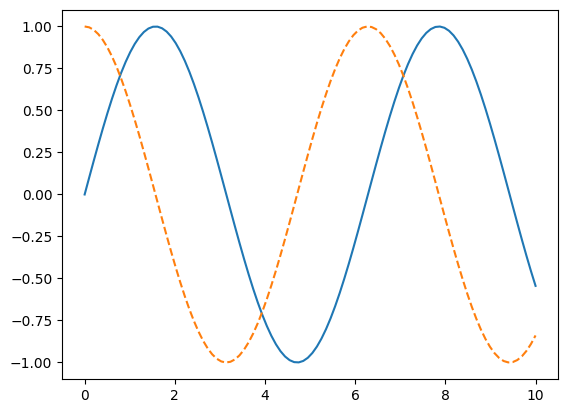

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
# ToDo: create np-array ranging from 0 to 10 with 100 samples (Hint! use linspace)
x = np.linspace(0, 10, 100)
# ToDo: Plot the x vs sin(x) using one dashed line and plot to the same figure.
plt.plot(x, np.sin(x), '-')   # yksi viiva
plt.plot(x, np.cos(x), '--')  # kaksi viivaa


Output Figure:

![](01-Fig-01.png)

### Saving Figures to File

One nice feature of Matplotlib is the ability to save figures in a wide variety of formats. Saving a figure can be done using the savefig() command. For example, to save the previous figure as a PNG file, you can run this:

In [2]:
# ToDo: save the previous figure to the file called 'my_figure.png'
plt.savefig('my_figure.png')

<Figure size 640x480 with 0 Axes>

-rw-r--r-- 1 Nat 197121 2.4K Mar 23 12:02 my_figure.png


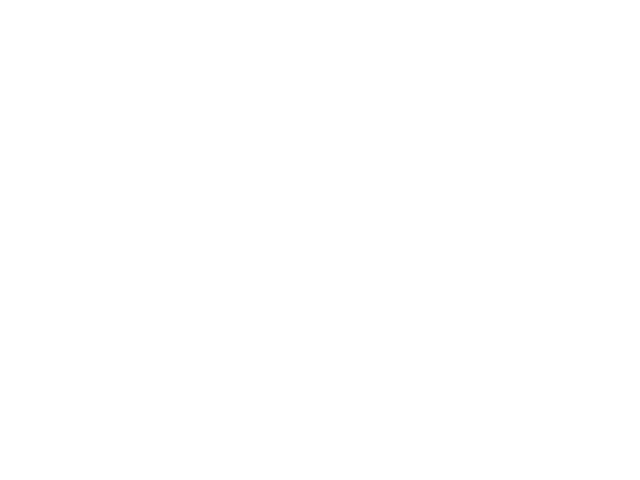

In [3]:
# just to test the image
!ls -lh my_figure.png

from IPython.display import Image
Image('my_figure.png')

In savefig(), the file format is inferred from the extension of the given filename. Depending on what backends you have installed, many different file formats are available. The list of supported file types can be found for your system by using the following method of the figure canvas object:

> Note that when saving your figure, it's not necessary to use plt.show() or related commands discussed earlier.

In [4]:
# ToDo: Find out which filetypes are supported by your backend (Hint: use get_supported_filetypes())
print(plt.gcf().canvas.get_supported_filetypes())


{'eps': 'Encapsulated Postscript', 'jpg': 'Joint Photographic Experts Group', 'jpeg': 'Joint Photographic Experts Group', 'pdf': 'Portable Document Format', 'pgf': 'PGF code for LaTeX', 'png': 'Portable Network Graphics', 'ps': 'Postscript', 'raw': 'Raw RGBA bitmap', 'rgba': 'Raw RGBA bitmap', 'svg': 'Scalable Vector Graphics', 'svgz': 'Scalable Vector Graphics', 'tif': 'Tagged Image File Format', 'tiff': 'Tagged Image File Format', 'webp': 'WebP Image Format'}


<Figure size 640x480 with 0 Axes>

## Two Interfaces for plotting

A potentially confusing feature of Matplotlib is its dual interfaces: a convenient MATLAB-style state-based interface, and a `more powerful object-oriented interface`. We'll quickly highlight the differences between the two here.

### MATLAB-style Interface

Matplotlib was originally written as a Python alternative for MATLAB users, and much of its syntax reflects that fact. The MATLAB-style tools are contained in the pyplot (plt) interface. For example, the following code will probably look quite familiar to MATLAB users:

It is important to note that this interface is stateful: it keeps track of the "current" figure and axes, which are where all plt commands are applied. You can get a reference to these using the plt.gcf() (get current figure) and plt.gca() (get current axes) routines.

While this stateful interface is fast and convenient for simple plots, it is easy to run into problems. For example, once the second panel is created, how can we go back and add something to the first? This is possible within the MATLAB-style interface, but a bit clunky. Fortunately, there is a better way.

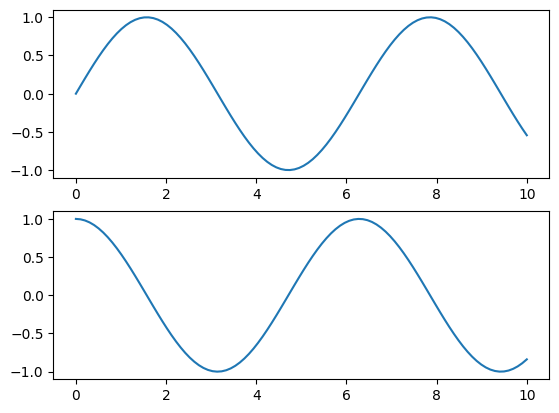

In [5]:
# ToDo: Create two subplots: 1st plots the sin(x) and the 2nd plots the cos(x)
# Hint: Use matlab stype interface
plt.figure()

# create the first of two panels and set current axis
plt.subplot(2, 1, 1)   # 2 riviä, 1 sarake, 1. paneeli
plt.plot(x, np.sin(x))
# create the second panel and set current axis
plt.subplot(2, 1, 2)   # 2. paneeli
plt.plot(x, np.cos(x))

Output Figure:

![](01-Fig-02.png)

### Object-oriented interface

The object-oriented interface is available for these more complicated situations, and for when you want more control over your figure. Rather than depending on some notion of an "active" figure or axes, in the object-oriented interface the plotting functions are methods of explicit Figure and Axes objects. To re-create the previous plot using this style of plotting, you might do the following:

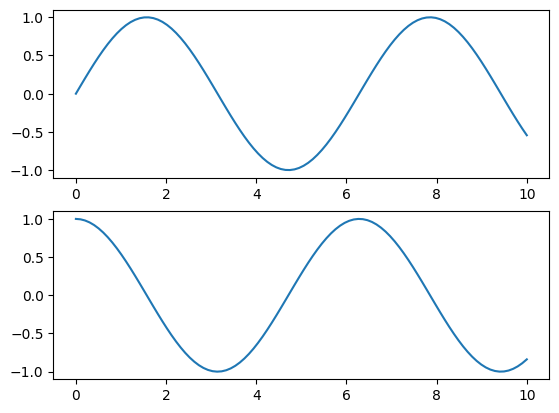

In [6]:
# ToDo: plot the same figure using Object-oriented interface
fig, ax = plt.subplots(2)
# First create a grid of plots
# ax will be an array of two Axes objects
ax[0].plot(x, np.sin(x))

# Call plot() method on the appropriate object
ax[1].plot(x, np.cos(x))

For more simple plots, the choice of which style to use is largely a matter of preference, but the object-oriented approach can become a necessity as plots become more complicated. Throughout this chapter, we will switch between the MATLAB-style and object-oriented interfaces, depending on what is most convenient. In most cases, the difference is as small as switching plt.plot() to ax.plot(), but there are a few gotchas that we will highlight as they come up in the following sections.

## Adjusting the Plot: Line Colors and Styles

The first adjustment you might wish to make to a plot is to control the line colors and styles. The plt.plot() function takes additional arguments that can be used to specify these. To adjust the color, you can use the color keyword, which accepts a string argument representing virtually any imaginable color. The color can be specified in a variety of ways:

> If no color is specified, Matplotlib will automatically cycle through a set of default colors for multiple lines.

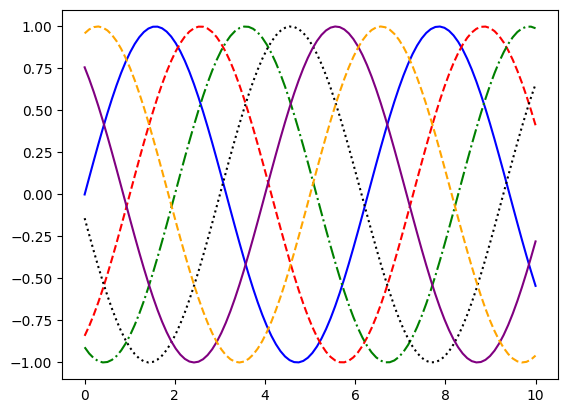

In [7]:
# ToDo: plot 6 sin-curves (from (x) to (x -5)) using different color and linestyle
styles = ['-', '--', '-.', ':', '-', '--']
colors = ['blue', 'red', 'green', 'black', 'purple', 'orange']

for i in range(6):
    plt.plot(x, np.sin(x - i), linestyle=styles[i], color=colors[i])

Output Figure:

![](01-Fig-03.png)

## Adjusting the Plot: Axes Limits

Matplotlib does a decent job of choosing default axes limits for your plot, but sometimes it's nice to have finer control. The most basic way to adjust axis limits is to use the plt.xlim() and plt.ylim() methods:

A useful related method is plt.axis() (note here the potential confusion between axes with an e, and axis with an i). The plt.axis() method allows you to set the x and y limits with a single call, by passing a list which specifies [xmin, xmax, ymin, ymax]:

The plt.axis() method goes even beyond this, allowing you to do things like automatically tighten the bounds around the current plot:

It allows even higher-level specifications, such as ensuring an equal aspect ratio so that on your screen, one unit in x is equal to one unit in y:

## Labeling Plots

As the last piece of this section, we'll briefly look at the labeling of plots: titles, axis labels, and simple legends.

Titles and axis labels are the simplest such labels—there are methods that can be used to quickly set them:

Text(0, 0.5, 'sin(x)')

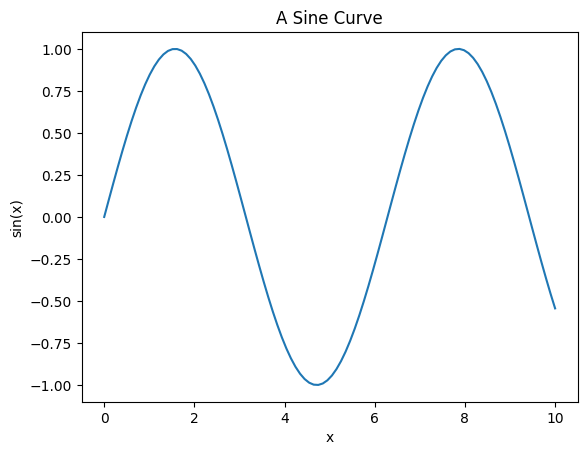

In [8]:
# ToDo: plot x vs sin(x) and 
plt.plot(x, np.sin(x))
# - set title of the plot to "A Sine curve"
plt.title("A Sine Curve")
# - set the x axel label to x
plt.xlabel("x")
# - set the y axel label to sin(x)
plt.ylabel("sin(x)")

Output Figure:

![](01-Fig-04.png)

## Simple Scatter Plots

Another commonly used plot type is the simple scatter plot, a close cousin of the line plot. Instead of points being joined by line segments, here the points are represented individually with a dot, circle, or other shape. We’ll start by setting up the notebook for plotting and importing the functions we will use:

### Scatter Plots with plt.plot

In the previous section we looked at plt.plot/ax.plot to produce line plots. It turns out that this same function can produce scatter plots as well:

The third argument in the function call is a character that represents the type of symbol used for the plotting. Just as you can specify options such as '-', '--' to control the line style, the marker style has its own set of short string codes. The full list of available symbols can be seen in the documentation of plt.plot, or in Matplotlib's online documentation. Most of the possibilities are fairly intuitive, and we'll show a number of the more common ones here:

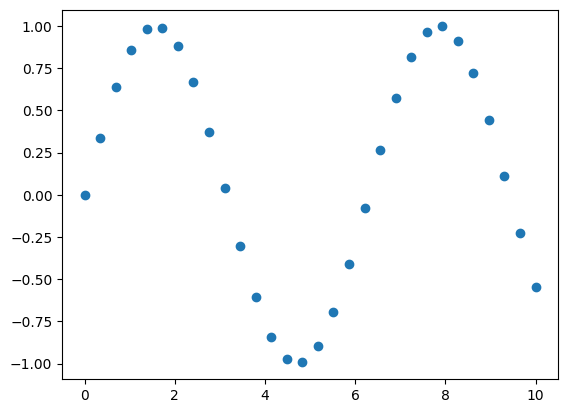

In [9]:
# ToDo: Plot sin curve using just dots (use plt.plot() function)
# Hint: set x axel values from 0 to 10 using 30 items
x30 = np.linspace(0, 10, 30)
plt.plot(x30, np.sin(x30), 'o')

Output Figure:

![](01-Fig-05.png)

### Scatter Plots with plt.scatter

A second, more powerful method of creating scatter plots is the plt.scatter function, which can be used very similarly to the plt.plot function:

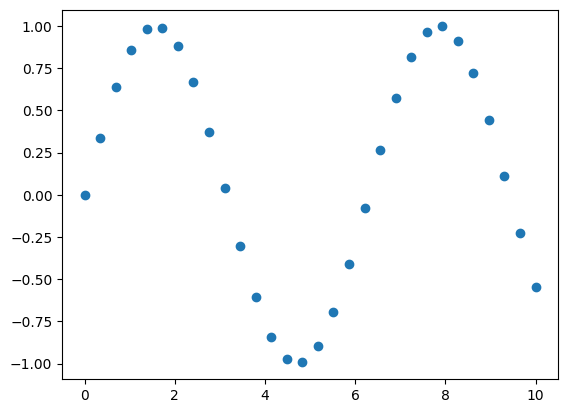

In [10]:
# ToDo: Plot the same figure as above, but use the scatter function instead
plt.scatter(x30, np.sin(x30))

The primary difference of plt.scatter from plt.plot is that it can be used to create scatter plots where the properties of each individual point (size, face color, edge color, etc.) can be individually controlled or mapped to data.

## Histograms, Binnings, and Density

A simple histogram can be a great first step in understanding a dataset. 

(array([   2.,    7.,   16.,   27.,   46.,   97.,  162.,  260.,  364.,
         577.,  711.,  810.,  968., 1050., 1062.,  945.,  845.,  667.,
         493.,  354.,  209.,  140.,   93.,   56.,   17.,   12.,    6.,
           2.,    0.,    2.]),
 array([-3.64274776, -3.38057978, -3.11841179, -2.85624381, -2.59407583,
        -2.33190785, -2.06973987, -1.80757188, -1.5454039 , -1.28323592,
        -1.02106794, -0.75889995, -0.49673197, -0.23456399,  0.02760399,
         0.28977197,  0.55193996,  0.81410794,  1.07627592,  1.3384439 ,
         1.60061189,  1.86277987,  2.12494785,  2.38711583,  2.64928381,
         2.9114518 ,  3.17361978,  3.43578776,  3.69795574,  3.96012372,
         4.22229171]),
 <BarContainer object of 30 artists>)

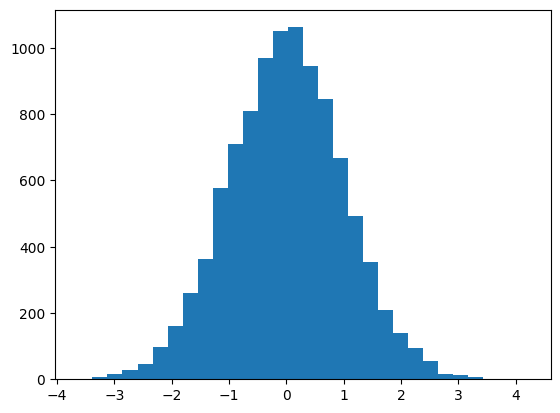

In [11]:
# ToDo: generate 10000 random samples and plot the histogram of the dataset using 30 bins
# Note! the histogram changes at every run
data = np.random.randn(10000)
plt.hist(data, bins=30)

Output Figure:

![](01-Fig-07.png)